## Setup and Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 11

## Load Data

In [3]:
df = pd.read_csv("/Users/mahmoudelboghdadi/Downloads/Chicago-Crime-Analytics/data/processed/chicago_crime_clean.csv")
df['date'] = pd.to_datetime(df['date'])

print(f"Total Records: {len(df):,}")
print(f"Date Range: {df['date'].min().date()} to {df['date'].max().date()}")
print(f"Columns: {len(df.columns)}")
print(f"Memory Usage: {df.memory_usage(deep=True).sum() / 1024**2:.1f} MB")


print("\nSample Records:")
df.head()

Total Records: 1,234,830
Date Range: 2021-01-01 to 2026-02-19
Columns: 37
Memory Usage: 1129.2 MB

Sample Records:


,id,case_number,date,block,iucr,primary_type,description,location_description,arrest,domestic,...,day_name,is_weekend,quarter,week_of_year,time_of_day,severity_level,has_valid_coords,is_cleared,is_high_severity,location_category
0,12258940,JE100430,2021-01-01 09:08:00,066XX W IRVING PARK RD,0610,Burglary,Forcible Entry,GROCERY FOOD STORE,False,False,...,Friday,0,1,53,Morning,6.0,True,0,0,Commercial
1,12560079,JE466899,2021-01-01 09:18:00,022XX N LAVERGNE AVE,1050,Other Crimes,Commercial Sex Acts,RESIDENCE,False,True,...,Friday,0,1,53,Morning,3.0,True,0,0,Residence
2,12260566,JE102008,2021-01-01 09:20:00,048XX N WINTHROP AVE,1310,Criminal Damage,To Property,RESIDENCE - GARAGE,False,False,...,Friday,0,1,53,Morning,4.0,False,0,0,Residence
3,12259844,JE101011,2021-01-01 09:29:00,030XX S BONFIELD ST,1320,Criminal Damage,To Vehicle,STREET,False,False,...,Friday,0,1,53,Morning,4.0,True,0,0,Street
4,12258917,JE100538,2021-01-01 09:30:00,028XX S WALLACE ST,5001,Other Offense,Other Crime Involving Property,APARTMENT,False,False,...,Friday,0,1,53,Morning,3.0,True,0,0,Residence


## Data Quality Assessment

In [4]:
print("="*70)
print("DATA QUALITY ASSESSMENT")
print("="*70)

quality_report = pd.DataFrame({
    'Column': df.columns,
    'Data Type': df.dtypes,
    'Non-Null Count': df.count(),
    'Null Count': df.isnull().sum(),
    'Null Percentage': (df.isnull().sum() / len(df) * 100).round(2),
    'Unique Values': df.nunique()
})

print(quality_report.to_string(index=False))


critical_columns = ['date', 'primary_type', 'latitude', 'longitude', 'district']
quality_scores = []

for col in critical_columns:
    completeness = (df[col].notna().sum() / len(df)) * 100
    quality_scores.append(completeness)
    status = "✓" if completeness > 95 else "⚠" if completeness > 80 else "✗"
    print(f"{status} {col:20s}: {completeness:5.1f}% complete")

avg_quality = np.mean(quality_scores)
print(f"\nOverall Data Quality Score: {avg_quality:.1f}/100")

DATA QUALITY ASSESSMENT
              Column      Data Type  Non-Null Count  Null Count  Null Percentage  Unique Values
                  id          int64         1234830           0             0.00        1234830
         case_number         object         1234830           0             0.00        1234675
                date datetime64[ns]         1234830           0             0.00         608887
               block         object         1234830           0             0.00          36872
                iucr         object         1234830           0             0.00            368
        primary_type         object         1234830           0             0.00             27
         description         object         1234830           0             0.00            344
location_description         object         1234830           0             0.00            151
              arrest           bool         1234830           0             0.00              2
            dome

## Descriptive Statistics

In [15]:
total_incidents = len(df)
arrests = df['arrest'].sum()
arrest_rate = (arrests / total_incidents) * 100
domestic_cases = df['domestic'].sum()
high_severity = df['is_high_severity'].sum()

print(f"\nCrime Volume Metrics:")
print(f"Total Incidents: {total_incidents:,}")
print(f"Total Arrests: {arrests:,} ({arrest_rate:.1f}%)")
print(f"Domestic Violence Cases: {domestic_cases:,} ({domestic_cases/total_incidents*100:.1f}%)")
print(f"High Severity Crimes: {high_severity:,} ({high_severity/total_incidents*100:.1f}%)")

date_range_days = (df['date'].max() - df['date'].min()).days
avg_daily_crimes = total_incidents / date_range_days

print(f"\nTemporal Coverage:")
print(f"Date Range: {date_range_days:,} days")
print(f"Average Daily Crimes: {avg_daily_crimes:.1f}")

print(f"\nGeographic Coverage:")
print(f"Unique Districts: {df['district'].nunique()}")
print(f"Unique Beats: {df['beat'].nunique()}")
print(f"Records with Coordinates: {df['has_valid_coords'].sum():,} ({df['has_valid_coords'].sum()/total_incidents*100:.1f}%)")


Crime Volume Metrics:
Total Incidents: 1,234,830
Total Arrests: 164,802 (13.3%)
Domestic Violence Cases: 237,785 (19.3%)
High Severity Crimes: 206,354 (16.7%)

Temporal Coverage:
Date Range: 1,874 days
Average Daily Crimes: 658.9

Geographic Coverage:
Unique Districts: 23
Unique Beats: 275
Records with Coordinates: 1,219,409 (98.8%)


## Crime Type Analysis

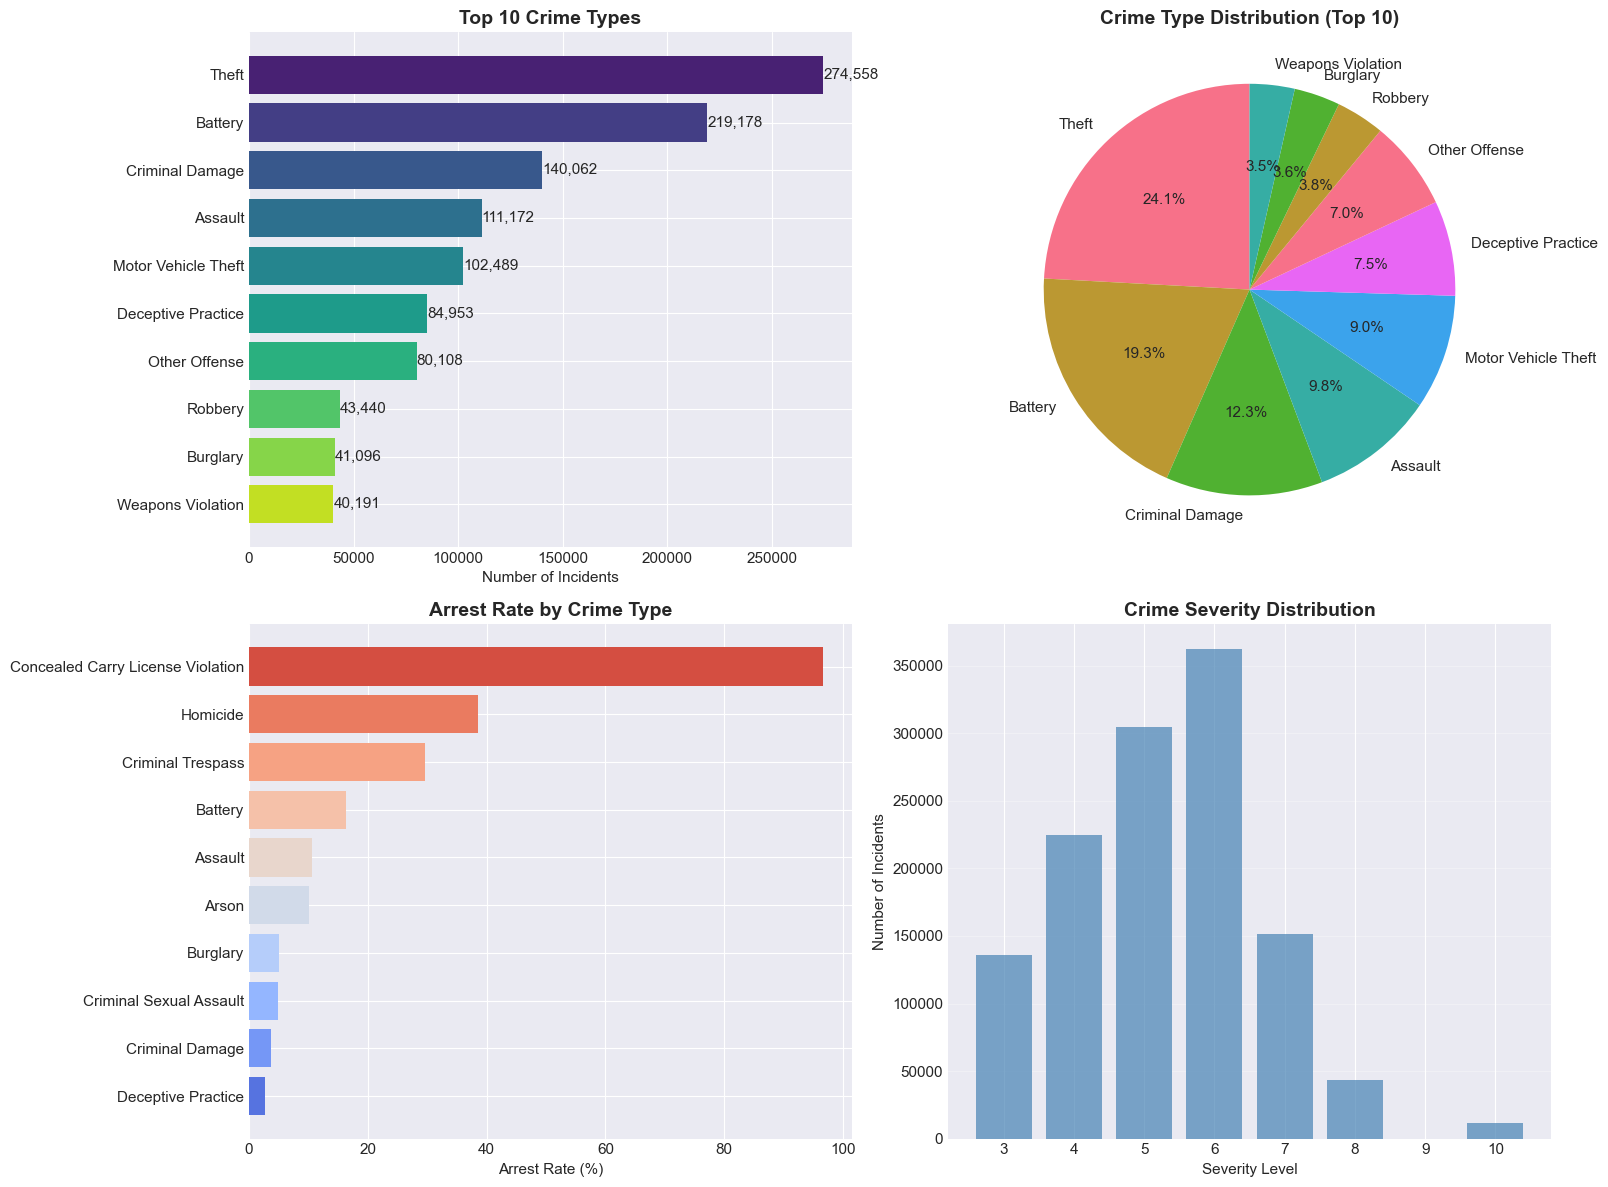

In [16]:

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Top 10 Crime Types
top_crimes = df['primary_type'].value_counts().head(10)
axes[0, 0].barh(range(len(top_crimes)), top_crimes.values, color=sns.color_palette("viridis", 10))
axes[0, 0].set_yticks(range(len(top_crimes)))
axes[0, 0].set_yticklabels(top_crimes.index)
axes[0, 0].set_xlabel('Number of Incidents')
axes[0, 0].set_title('Top 10 Crime Types', fontsize=14, fontweight='bold')
axes[0, 0].invert_yaxis()

for i, v in enumerate(top_crimes.values):
    axes[0, 0].text(v + 100, i, f'{v:,}', va='center')


crime_category = df.groupby('primary_type').size().sort_values(ascending=False).head(10)
axes[0, 1].pie(crime_category.values, labels=crime_category.index, autopct='%1.1f%%', startangle=90)
axes[0, 1].set_title('Crime Type Distribution (Top 10)', fontsize=14, fontweight='bold')

arrest_by_crime = df.groupby('primary_type').agg({
    'arrest': ['sum', 'count']
}).head(10)
arrest_by_crime.columns = ['Arrests', 'Total']
arrest_by_crime['Rate'] = (arrest_by_crime['Arrests'] / arrest_by_crime['Total'] * 100)
arrest_by_crime = arrest_by_crime.sort_values('Rate', ascending=True).tail(10)

axes[1, 0].barh(range(len(arrest_by_crime)), arrest_by_crime['Rate'].values, 
                color=sns.color_palette("coolwarm", 10))
axes[1, 0].set_yticks(range(len(arrest_by_crime)))
axes[1, 0].set_yticklabels(arrest_by_crime.index)
axes[1, 0].set_xlabel('Arrest Rate (%)')
axes[1, 0].set_title('Arrest Rate by Crime Type', fontsize=14, fontweight='bold')

severity_dist = df['severity_level'].value_counts().sort_index()
axes[1, 1].bar(severity_dist.index, severity_dist.values, color='steelblue', alpha=0.7)
axes[1, 1].set_xlabel('Severity Level')
axes[1, 1].set_ylabel('Number of Incidents')
axes[1, 1].set_title('Crime Severity Distribution', fontsize=14, fontweight='bold')
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../docs/screenshots/crime_type_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

## Temporal Pattern Analysis

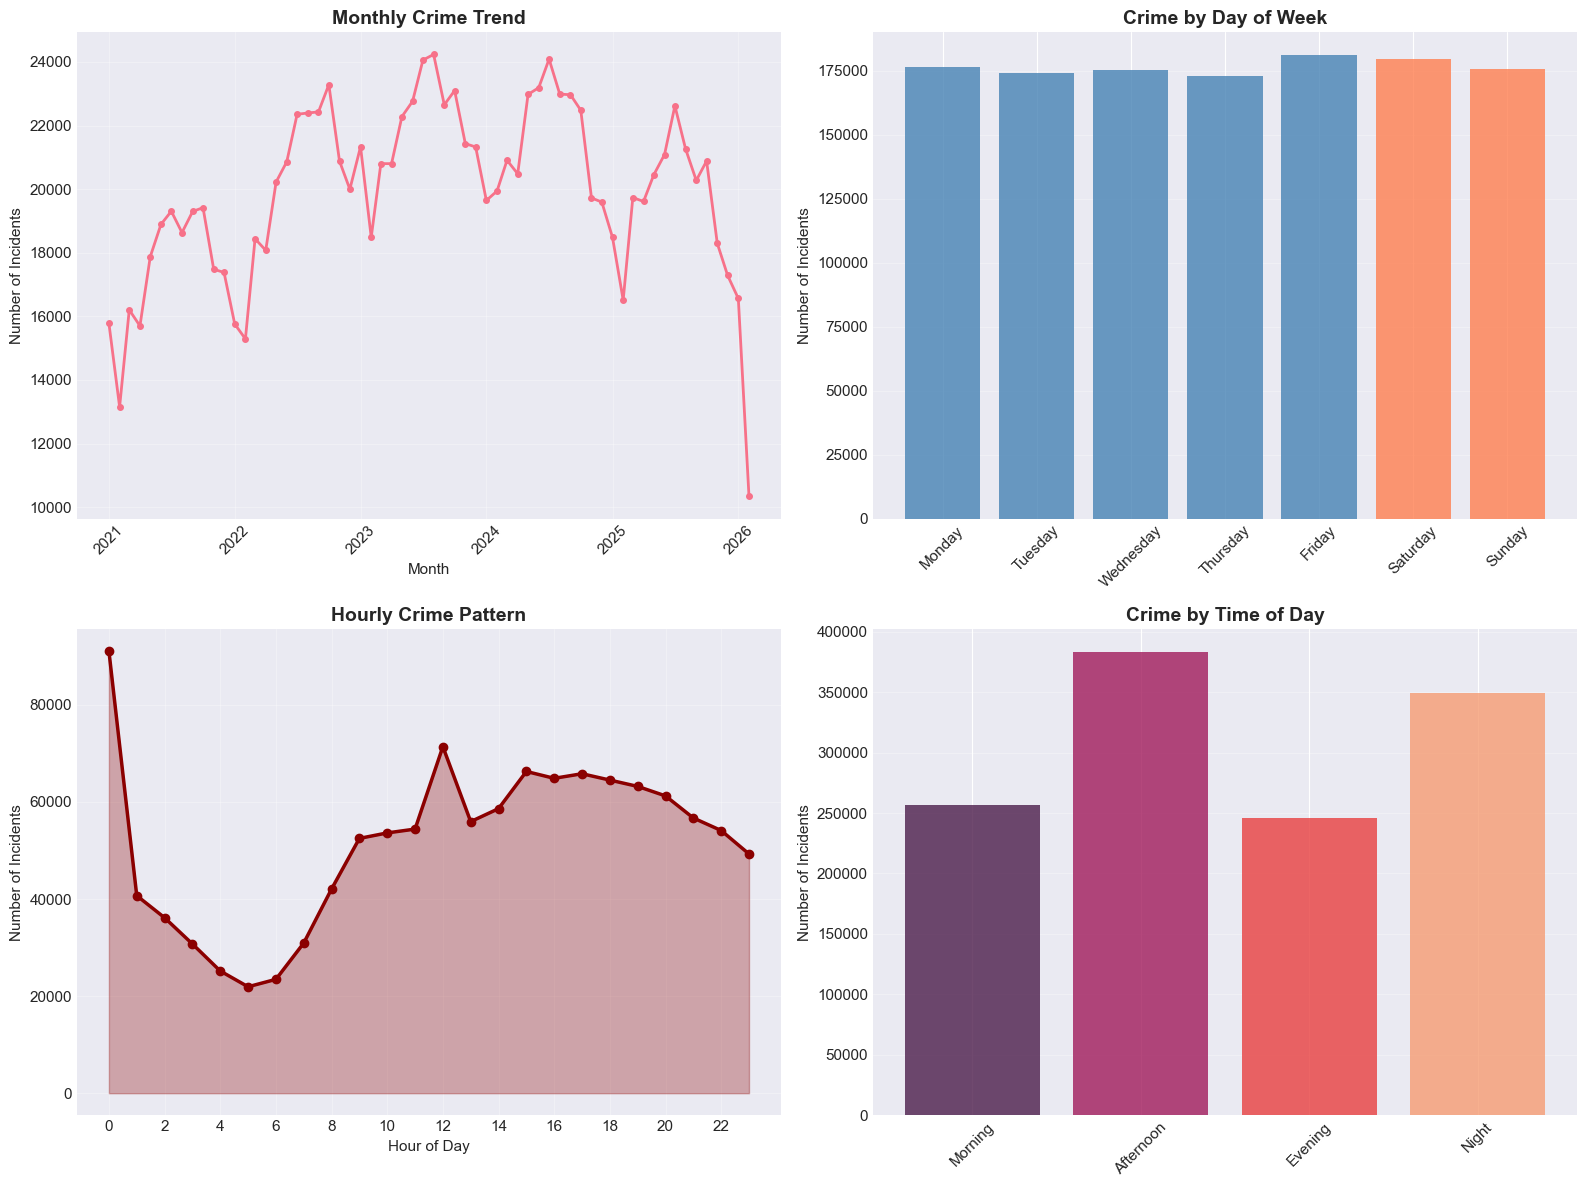

In [17]:

fig, axes = plt.subplots(2, 2, figsize=(16, 12))


monthly_crimes = df.groupby(df['date'].dt.to_period('M')).size()
monthly_crimes.index = monthly_crimes.index.to_timestamp()

axes[0, 0].plot(monthly_crimes.index, monthly_crimes.values, marker='o', linewidth=2, markersize=4)
axes[0, 0].set_xlabel('Month')
axes[0, 0].set_ylabel('Number of Incidents')
axes[0, 0].set_title('Monthly Crime Trend', fontsize=14, fontweight='bold')
axes[0, 0].grid(alpha=0.3)
axes[0, 0].tick_params(axis='x', rotation=45)


day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_crimes = df.groupby('day_name').size().reindex(day_order)

axes[0, 1].bar(range(len(day_crimes)), day_crimes.values, 
               color=['steelblue']*5 + ['coral']*2, alpha=0.8)
axes[0, 1].set_xticks(range(len(day_crimes)))
axes[0, 1].set_xticklabels(day_crimes.index, rotation=45)
axes[0, 1].set_ylabel('Number of Incidents')
axes[0, 1].set_title('Crime by Day of Week', fontsize=14, fontweight='bold')
axes[0, 1].grid(axis='y', alpha=0.3)


hourly_crimes = df.groupby('hour').size()

axes[1, 0].plot(hourly_crimes.index, hourly_crimes.values, marker='o', 
                linewidth=2.5, color='darkred', markersize=6)
axes[1, 0].fill_between(hourly_crimes.index, hourly_crimes.values, alpha=0.3, color='darkred')
axes[1, 0].set_xlabel('Hour of Day')
axes[1, 0].set_ylabel('Number of Incidents')
axes[1, 0].set_title('Hourly Crime Pattern', fontsize=14, fontweight='bold')
axes[1, 0].set_xticks(range(0, 24, 2))
axes[1, 0].grid(alpha=0.3)


time_crimes = df.groupby('time_of_day').size()
time_order = ['Morning', 'Afternoon', 'Evening', 'Night']
time_crimes = time_crimes.reindex(time_order)

axes[1, 1].bar(time_crimes.index, time_crimes.values, 
               color=sns.color_palette("rocket", 4), alpha=0.8)
axes[1, 1].set_ylabel('Number of Incidents')
axes[1, 1].set_title('Crime by Time of Day', fontsize=14, fontweight='bold')
axes[1, 1].tick_params(axis='x', rotation=45)
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../docs/screenshots/temporal_patterns.png', dpi=300, bbox_inches='tight')
plt.show()

## Geographic Analysis

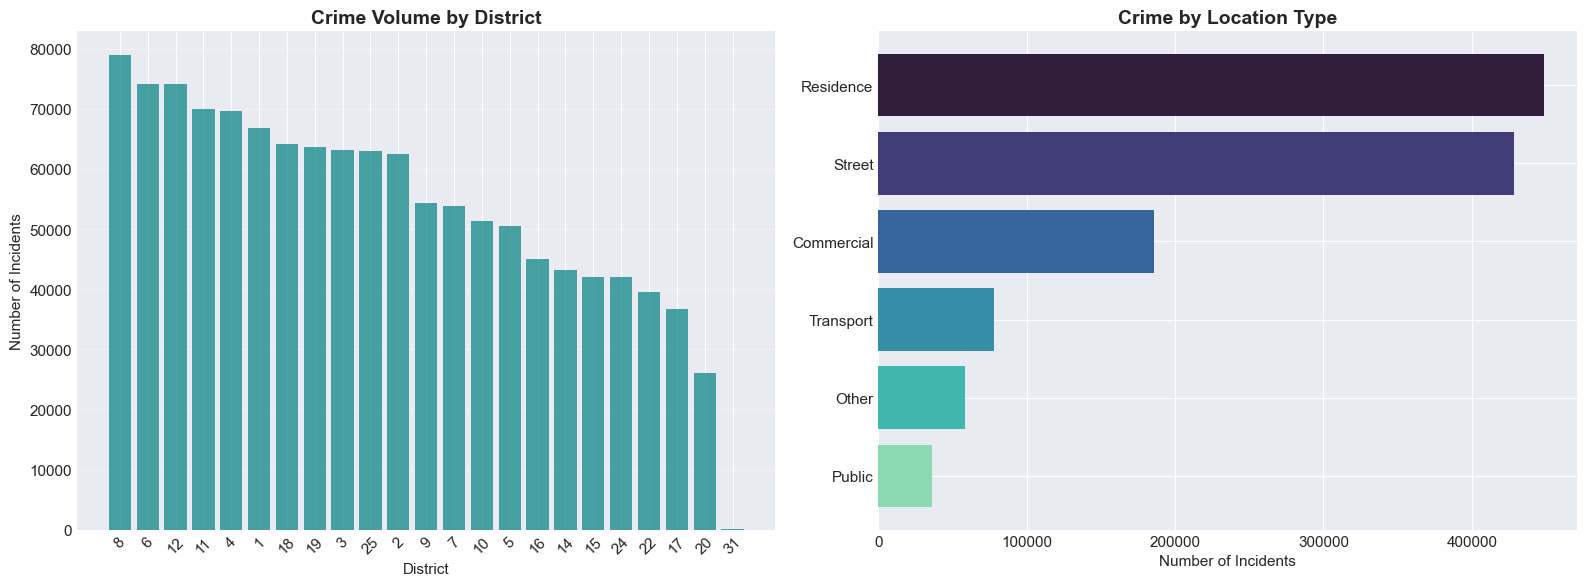

In [18]:

fig, axes = plt.subplots(1, 2, figsize=(16, 6))


district_crimes = df[df['district'] > 0].groupby('district').size().sort_values(ascending=False)

axes[0].bar(range(len(district_crimes)), district_crimes.values, color='teal', alpha=0.7)
axes[0].set_xticks(range(len(district_crimes)))
axes[0].set_xticklabels(district_crimes.index, rotation=45)
axes[0].set_xlabel('District')
axes[0].set_ylabel('Number of Incidents')
axes[0].set_title('Crime Volume by District', fontsize=14, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)


location_crimes = df.groupby('location_category').size().sort_values(ascending=False)

axes[1].barh(range(len(location_crimes)), location_crimes.values, 
             color=sns.color_palette("mako", len(location_crimes)))
axes[1].set_yticks(range(len(location_crimes)))
axes[1].set_yticklabels(location_crimes.index)
axes[1].set_xlabel('Number of Incidents')
axes[1].set_title('Crime by Location Type', fontsize=14, fontweight='bold')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('../docs/screenshots/geographic_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

## Interactive Crime Heatmap

In [10]:
geo_data = df[df['has_valid_coords']].sample(n=min(50000, len(df)), random_state=42)

fig = px.density_mapbox(
    geo_data,
    lat='latitude',
    lon='longitude',
    radius=8,
    center=dict(lat=41.85, lon=-87.65),
    zoom=10,
    mapbox_style="open-street-map",
    title='Chicago Crime Density Heatmap',
    color_continuous_scale='Reds',
    opacity=0.6
)

fig.update_layout(
    height=700,
    title_font_size=18,
    margin=dict(l=0, r=0, t=40, b=0)
)

fig.write_html('../docs/screenshots/crime_heatmap.html')
fig.show()

/var/folders/2m/_4hckxq90g52zkvfsjt8x_p40000gn/T/ipykernel_2005/2783003791.py:3: DeprecationWarning: *density_mapbox* is deprecated! Use *density_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig = px.density_mapbox(


## Correlation Analysis

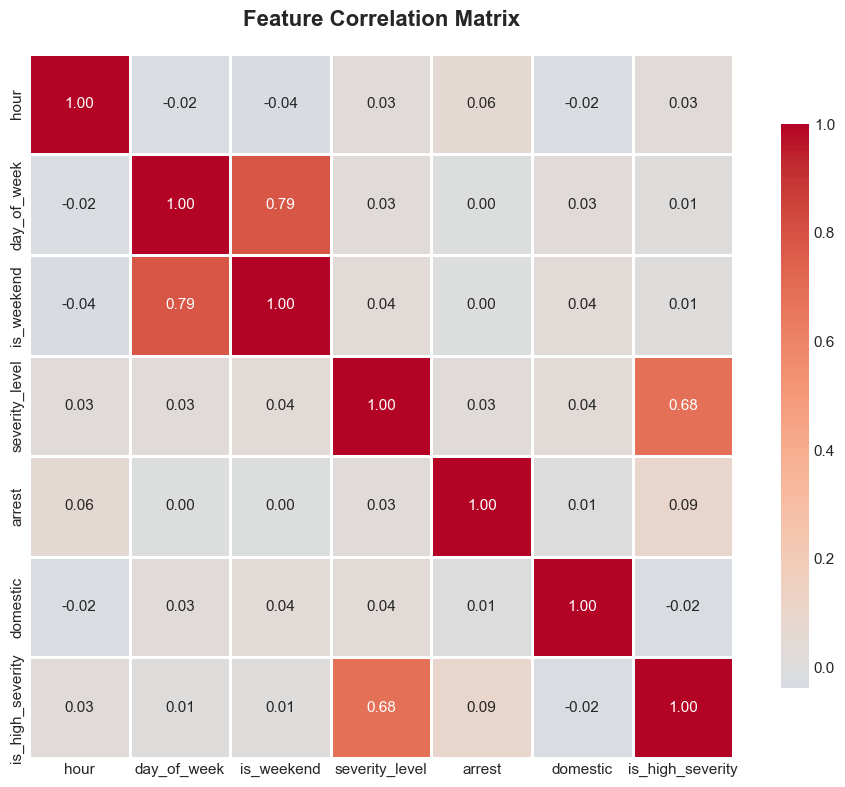


Key Correlations:
     Feature 1        Feature 2  Correlation
   day_of_week       is_weekend     0.788863
severity_level is_high_severity     0.683736
        arrest is_high_severity     0.090943
          hour           arrest     0.056515
    is_weekend         domestic     0.039376
severity_level         domestic     0.036954
          hour       is_weekend    -0.036786
    is_weekend   severity_level     0.035702
severity_level           arrest     0.031058
          hour   severity_level     0.030792


In [12]:
numeric_cols = ['hour', 'day_of_week', 'is_weekend', 'severity_level', 
                'arrest', 'domestic', 'is_high_severity']

correlation_matrix = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Matrix', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('../docs/screenshots/correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nKey Correlations:")
corr_pairs = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        corr_pairs.append({
            'Feature 1': correlation_matrix.columns[i],
            'Feature 2': correlation_matrix.columns[j],
            'Correlation': correlation_matrix.iloc[i, j]
        })

corr_df = pd.DataFrame(corr_pairs).sort_values('Correlation', key=abs, ascending=False)
print(corr_df.head(10).to_string(index=False))

## Summary Statistics Export

In [14]:
summary_stats = {
    'Total Incidents': len(df),
    'Date Range': f"{df['date'].min().date()} to {df['date'].max().date()}",
    'Arrest Rate': f"{(df['arrest'].sum() / len(df) * 100):.1f}%",
    'Domestic Violence Rate': f"{(df['domestic'].sum() / len(df) * 100):.1f}%",
    'High Severity Rate': f"{(df['is_high_severity'].sum() / len(df) * 100):.1f}%",
    'Most Common Crime': df['primary_type'].mode()[0],
    'Peak Hour': df['hour'].mode()[0],
    'Peak Day': df['day_name'].mode()[0],
    'Districts Covered': df['district'].nunique(),
    'Data Quality Score': f"{avg_quality:.1f}/100"
}

summary_df = pd.DataFrame(list(summary_stats.items()), columns=['Metric', 'Value'])
summary_df.to_csv('/Users/mahmoudelboghdadi/Downloads/Chicago-Crime-Analytics/data/output/eda_summary.csv', index=False)

print("="*70)
print("EXPLORATORY DATA ANALYSIS COMPLETE")
print("="*70)
print("\nKey Findings:")
for metric, value in summary_stats.items():
    print(f"{metric}: {value}")

EXPLORATORY DATA ANALYSIS COMPLETE

Key Findings:
Total Incidents: 1234830
Date Range: 2021-01-01 to 2026-02-19
Arrest Rate: 13.3%
Domestic Violence Rate: 19.3%
High Severity Rate: 16.7%
Most Common Crime: Theft
Peak Hour: 0
Peak Day: Friday
Districts Covered: 23
Data Quality Score: 99.5/100
